In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [ ]:
df = pd.read_csv(r'D:\Projects\Money Vest\Gold Price Prediction\Gold Price.csv')

In [3]:
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,2025-01-06,77149,77309,77542,76545,27160,0.44
1,2025-01-03,76813,77246,78600,76613,60,-0.05
2,2025-01-02,76849,76849,76849,76849,0,0.83
3,2025-01-01,76214,76232,76302,76053,60,-0.02
4,2024-12-31,76232,75680,76970,75572,1920,0.95


In [4]:
print(df.columns)

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Volume', 'Chg%'], dtype='object')


In [5]:
print(df.describe())

              Price          Open          High           Low         Volume  \
count   2848.000000   2848.000000   2848.000000   2848.000000    2848.000000   
mean   41221.788624  41223.038975  41443.228230  41002.117275   12592.610253   
std    14374.500657  14375.130049  14451.199655  14300.609162   10643.504531   
min    24545.000000  24583.000000  24635.000000  24470.000000       0.000000   
25%    29168.750000  29154.000000  29294.500000  29002.000000    6307.500000   
50%    33939.000000  33945.000000  34229.500000  33743.000000   10830.000000   
75%    50824.000000  50819.000000  51071.000000  50551.000000   16472.500000   
max    79257.000000  79264.000000  79999.000000  78888.000000  106920.000000   

              Chg%  
count  2848.000000  
mean      0.037324  
std       0.829900  
min      -5.980000  
25%      -0.380000  
50%       0.040000  
75%       0.460000  
max       5.300000  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2848 non-null   object 
 1   Price   2848 non-null   int64  
 2   Open    2848 non-null   int64  
 3   High    2848 non-null   int64  
 4   Low     2848 non-null   int64  
 5   Volume  2848 non-null   int64  
 6   Chg%    2848 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 155.9+ KB
None


There is no null values in the dataset

In [7]:
df.isnull().sum()

Date      0
Price     0
Open      0
High      0
Low       0
Volume    0
Chg%      0
dtype: int64

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,2025-01-06,77149,77309,77542,76545,27160,0.44
1,2025-01-03,76813,77246,78600,76613,60,-0.05
2,2025-01-02,76849,76849,76849,76849,0,0.83
3,2025-01-01,76214,76232,76302,76053,60,-0.02
4,2024-12-31,76232,75680,76970,75572,1920,0.95


# Feature Scaling

Sorting dataset by date

In [10]:
df = df.sort_values(by = 'Date')

In [11]:
df.head(5)

,Date,Price,Open,High,Low,Volume,Chg%
2847,2014-01-01,29542,29435,29598,29340,2930,0.25
2846,2014-01-02,29975,29678,30050,29678,3140,1.47
2845,2014-01-03,29727,30031,30125,29539,3050,-0.83
2844,2014-01-04,29279,29279,29279,29279,0,-1.51
2843,2014-01-06,29119,29300,29395,29051,24380,-0.55


In [12]:
df.shape

(2848, 7)

In [13]:
df.set_index('Date', inplace = True)

Graph

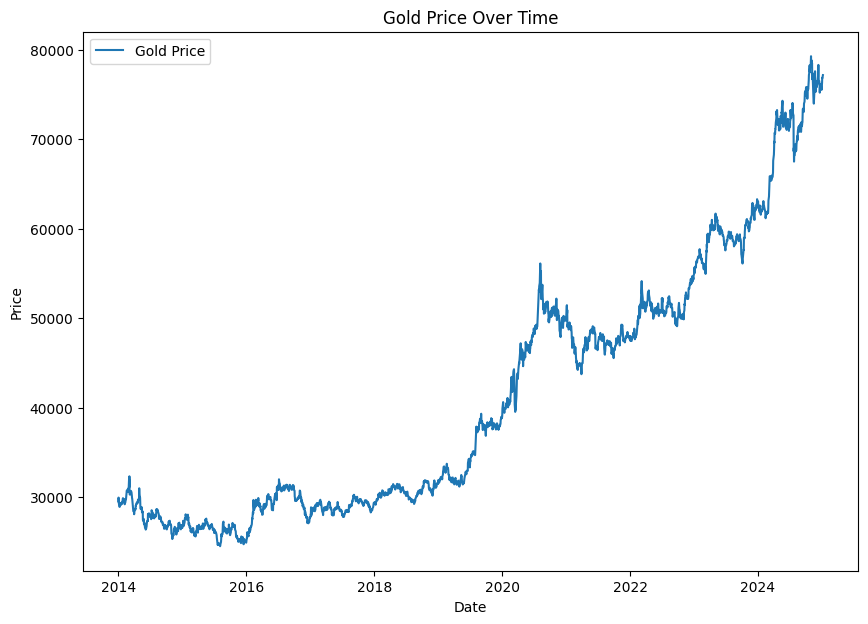

In [14]:
plt.figure(figsize=(10,7))
plt.plot(df['Price'], label='Gold Price')
plt.title("Gold Price Over Time")
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

Since we are predicting future prices using the previous day's data, our target column will contain the prices of next day

In [15]:
df['Target'] = df['Price'].shift(-1) # Create a target column for next day's price

In [16]:
df.head()

,Price,Open,High,Low,Volume,Chg%,Target
Date,,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25,29975.0
2014-01-02,29975,29678,30050,29678,3140,1.47,29727.0
2014-01-03,29727,30031,30125,29539,3050,-0.83,29279.0
2014-01-04,29279,29279,29279,29279,0,-1.51,29119.0
2014-01-06,29119,29300,29395,29051,24380,-0.55,28959.0


This drops last row where the target column will have NaN value

In [17]:
df = df.dropna() # Drop rows with NaN values

In [29]:
from sklearn.preprocessing import StandardScaler
import pickle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Price', 'Open', 'High', 'Low', 'Volume', 'Chg%']])
y = df['Target']
with open("gold_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model Training

Best ML models for prediction especially in a times series format are : Linear Regression(Simple interpretable), Random Forest Regressor(Handles non-linearities), XGBoost/ LightGBM(handles noise, fast)

# 1.Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression
model_linear = LinearRegression()
model_linear.fit(x_train, y_train)
y_linear_pred = model_linear.predict(x_test)

Metrics
- Mean Squared Error (MSE): Measures the average squared difference between actual and predicted values. Lower is better; it penalizes larger errors more.
- Mean Absolute Error (MAE): Measures the average absolute difference between actual and predicted values. Lower is better; it's easier to interpret as it's in the same unit as the target.
- R2 Score (Coefficient of Determination): Indicates how well the model explains the variance in the target variable. R2 ranges from 0 to 1 (closer to 1 is better). An R2 near 1 means predictions are very close to actual values.

In [21]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse_linear = mean_squared_error(y_test, y_linear_pred)
r2_linear = r2_score(y_test, y_linear_pred)
mae_linear = mean_absolute_error(y_test, y_linear_pred)
print(f"Linear Regression - MSE: {mse_linear}, R2: {r2_linear}, MAE: {mae_linear}")

Linear Regression - MSE: 129405.72000101651, R2: 0.9993823993389461, MAE: 240.73950933805602


Linear Regression 
- MSE: 129405.72000101651
- R2: 0.9993823993389461
- MAE: 240.73950933805602

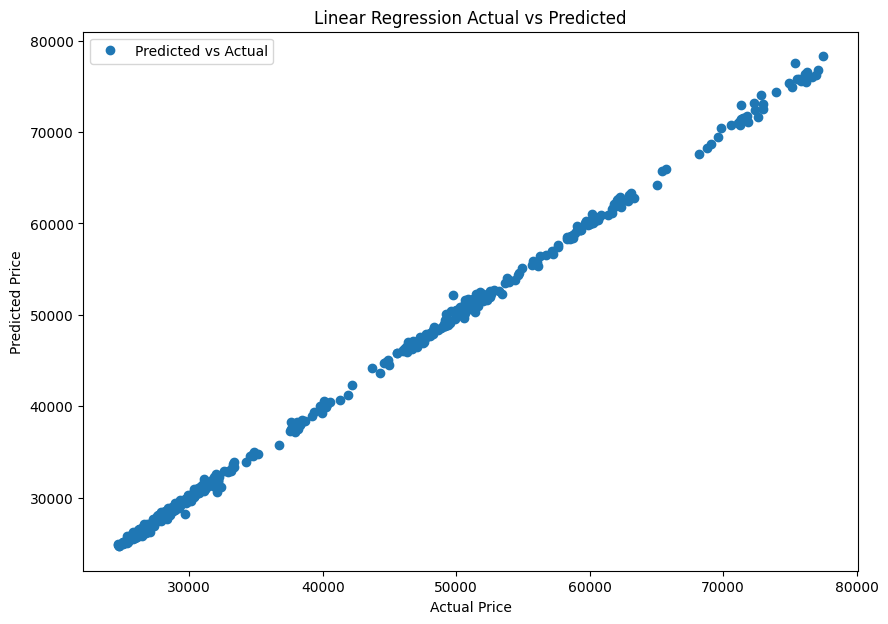

In [22]:
plt.figure(figsize=(10, 7))
plt.plot(y_test, y_linear_pred, 'o', label='Predicted vs Actual')
plt.title('Linear Regression Actual vs Predicted')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

# 2.Random Forest Regressor

In [23]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)#n_estimators is the number of trees in the forest
rf_model.fit(x_train, y_train)
y_rf_pred = rf_model.predict(x_test)


Metrics

In [24]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse_rf = mean_squared_error(y_test, y_rf_pred)
r2_rf = r2_score(y_test, y_rf_pred)
mae_rf = mean_absolute_error(y_test, y_rf_pred)
print(f"Random Forest Regressor - MSE: {mse_rf}, R2: {r2_rf}, MAE: {mae_rf}")

Random Forest Regressor - MSE: 153004.44009701765, R2: 0.9992697722840431, MAE: 262.7673508771931


Random Forest Regressor 
- MSE: 153004.44009701765
- R2: 0.9992697722840431
- MAE: 262.7673508771931

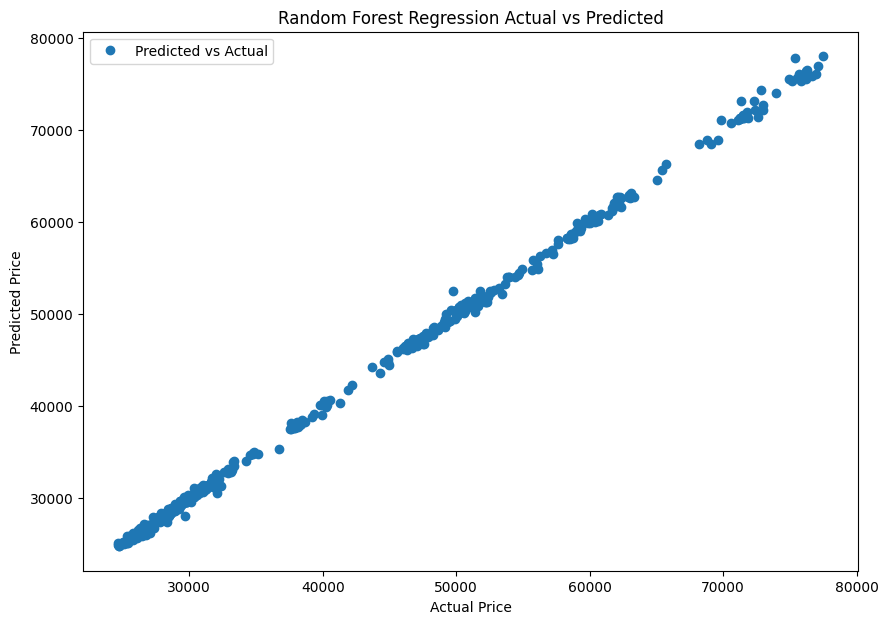

In [25]:
plt.figure(figsize=(10, 7))
plt.plot(y_test, y_rf_pred, 'o', label='Predicted vs Actual')
plt.title('Random Forest Regression Actual vs Predicted')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

# 3.XGBoost

In [26]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 42)
xgb_model.fit(x_train, y_train)
y_xgb_pred = xgb_model.predict(x_test)

Metrics

In [27]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse_xgb = mean_squared_error(y_test, y_xgb_pred)
r2_xgb = r2_score(y_test, y_xgb_pred)
mae_xgb = mean_absolute_error(y_test, y_xgb_pred)
print(f"XGBoost Regressor - MSE: {mse_xgb}, R2: {r2_xgb}, MAE: {mae_xgb}")

XGBoost Regressor - MSE: 163273.96186846684, R2: 0.9992207600500036, MAE: 276.6141207510965


XGBoost Regressor 
- MSE: 163273.96186846684
- R2: 0.9992207600500036
- MAE: 276.6141207510965

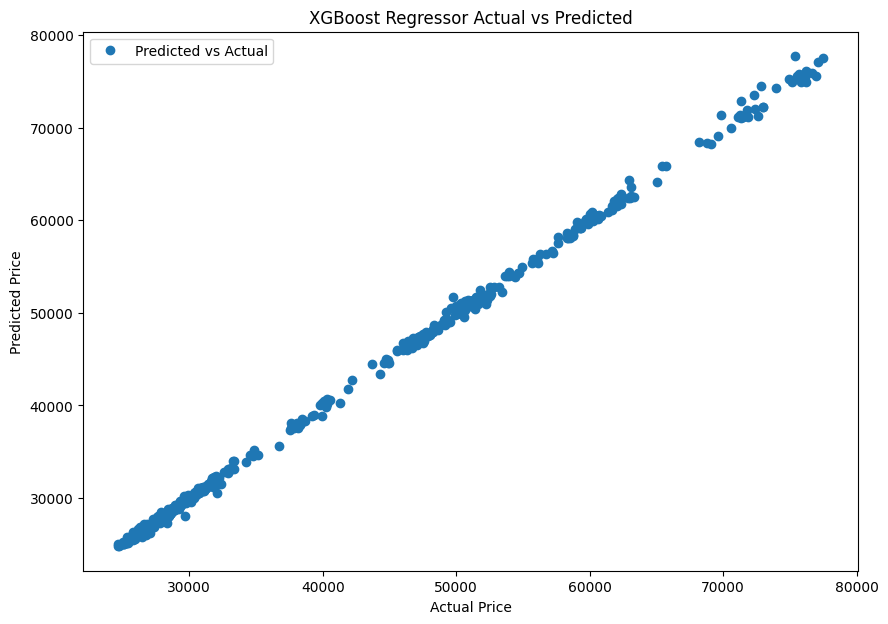

In [28]:
plt.figure(figsize=(10, 7))
plt.plot(y_test, y_xgb_pred, 'o', label='Predicted vs Actual')
plt.title('XGBoost Regressor Actual vs Predicted')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

In [30]:
with open("gold_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)